## Query Construction

**Translation notebook** rewrote the question into better *text* queries.
**This notebook** converts the question into a *structured* query - metadata filters
the database can enforce exactly (NL -> DSL).

Three query shapes handled:
- Pure metadata: "articles by Sarah" -> filter only
- Pure semantic: "responsive layouts" -> search_term only
- Hybrid: "Dan's articles about event loops" -> filter AND search_term

No vector store here at all - retrieval happens against a SQLite table.

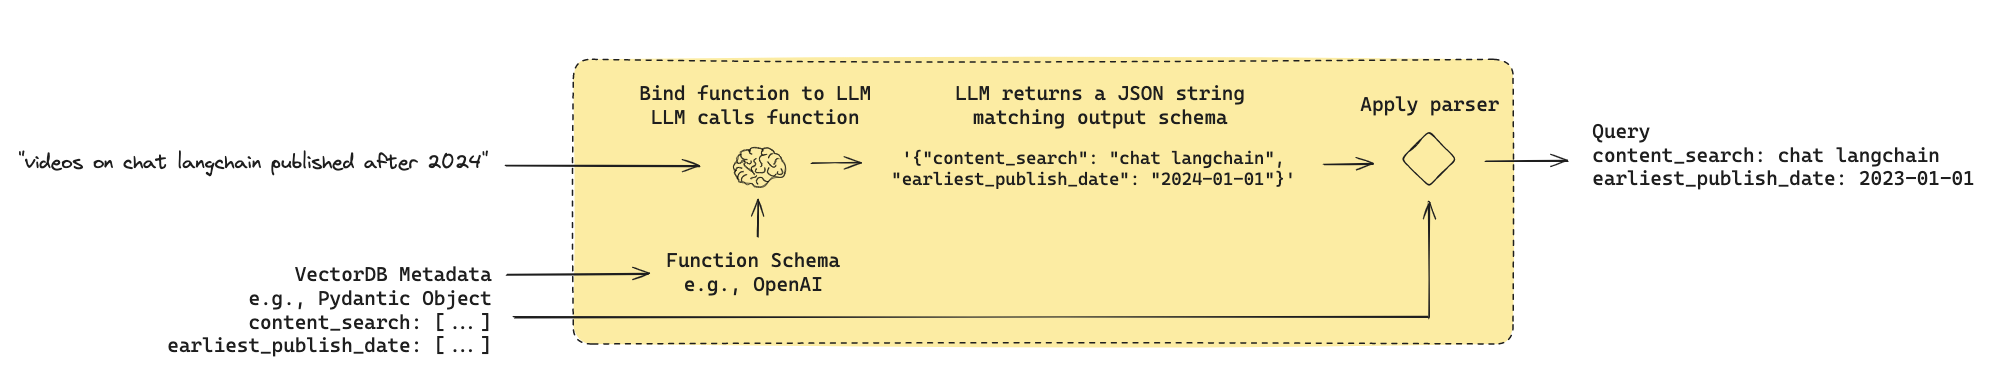

### Step 1 - Build the target database

Multi-step cell:
1. `create_engine` -> connection to a local SQLite file
2. declarative `Article` model -> ORM mapping for the `articles` table
3. `Base.metadata.create_all` -> DDL executed only if table missing
4. Session block -> seeds 8 sample rows (re-running re-inserts: duplicates possible)

In [ ]:
from sqlalchemy import create_engine, Column, Integer, String, select
from sqlalchemy.orm import declarative_base, Session

# 1. 🗄️ Create SQLite Engine
engine = create_engine("sqlite:///tech_articles.db")
Base = declarative_base()

# 2. 📝 Define Article Table Model
class Article(Base):
    __tablename__ = "articles"
    
    id = Column(Integer, primary_key=True)
    title = Column(String)
    author = Column(String)
    year = Column(Integer)
    topic = Column(String)
    content = Column(String)

# Create the table in SQLite
Base.metadata.create_all(engine)

# 3. 📥 Insert Sample Data using a Session
with Session(engine) as session:
    session.add_all([
        Article(title="Python Asyncio Deep Dive", author="Dan", year=2024, topic="python", content="Advanced guide to event loops."),
        Article(title="Getting Started with JavaScript", author="Sarah", year=2023, topic="javascript", content="Basics of closures."),
        Article(title="Go Concurrency Patterns", author="Dan", year=2024, topic="go", content="Understanding goroutines."),
        Article(title="Python for Beginners", author="Alex", year=2022, topic="python", content="Introduction to variables."),

        Article(title="Docker Containers Explained", author="Sarah", year=2024, topic="devops", content="Guide to containerizing applications."),
        Article(title="Advanced CSS Grid Layouts", author="Alex", year=2023, topic="css", content="Building responsive web layouts."),
        Article(title="JavaScript ES6+ Features", author="Sarah", year=2024, topic="javascript", content="Promises and async/await syntax."),
        Article(title="Python Data Science Basics", author="Alex", year=2024, topic="python", content="Pandas and NumPy for beginners.")
    ])
    session.commit()



print("Database and tables created with SQLAlchemy! ✅")

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="RAG-Routing"

### Step 2 - The query schema (the contract)

`ArticleQuery` defines EVERYTHING the LLM may extract - fields not in the schema
simply cannot be produced by `with_structured_output`.

- Optional fields default to `None` = "filter absent"
- `pretty_print()` iterates `model_fields` from the CLASS and prints only set values -
so you see the meaningful part of each parsed query, not noise

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional

class ArticleQuery(BaseModel):
    """Structured query for searching tech articles."""
    search_term: str = Field(description="The semantic search query text")
    author: Optional[str] = Field(None, description="Author's name if specified")
    year: Optional[int] = Field(None, description="Publication year if specified")
    topic: Optional[str] = Field(None, description="Programming language or topic if specified, secondary search query")

    def pretty_print(self) -> None:
        # Access model_fields from the CLASS, not the instance
        fields = type(self).model_fields
        
        for field_name, field_info in fields.items():
            current_value = getattr(self, field_name)
            
            # Get the default value safely from FieldInfo
            default_value = field_info.default
            
            # Only print if value is not None AND differs from the default
            if current_value is not None and current_value != default_value:
                print(f"{field_name}: {current_value}")

### Step 3 - Zero-shot analyzer

The system prompt encodes two non-obvious rules:
- **Exclusion rule**: a value extracted into a filter must NOT reappear in `search_term`
(otherwise "python" gets searched semantically AND filtered - double counting)
- **Null handling**: purely-metadata questions leave `search_term` empty

Same `with_structured_output(PydanticModel)` pattern as Multi Query - now producing
a DB-shaped object instead of question variants.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

llm = ChatOllama(model='gemma3:4b')

system = """You are an expert at converting natural language questions into structured database queries.

Follow these rules strictly:
1. EXCLUSION RULE: If a word/value is extracted into a metadata field (`author`, `year`, or `topic`), you MUST NOT include it in `search_term`.
2. `author`: Extract author names (e.g., "Dan", "Sarah").
3. `year`: Extract publication years as integers (e.g., 2024).
4. `topic`: Extract programming languages or main topics (e.g., "python", "javascript"). If none, leave as null/None.
5. `search_term`: Set to null/None if the question is purely about metadata filters (e.g., "articles by Dan"). Only use this for general text keywords.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{query}"),
])

structured_llm = llm.with_structured_output(ArticleQuery)

query_analyzer = prompt | structured_llm

# questions = [
#     "Show me all articles written by Dan.",
#     "Find Python articles published in 2024.",
#     "List all articles about JavaScript.",
#     "Find articles written by Sarah in 2024."
# ]

# full_chain = query_analyzer.batch(questions)
# print(full_chain, end="\n")

# for res in full_chain:
#     res.pretty_print()

### Step 4 - Few-shot variant

Same `FewShotChatMessagePromptTemplate` mechanism as step-back prompting (`rag_query_translation`).
Examples demonstrate the tricky cases explicitly: exclusion rule, multi-field extraction,
hybrid queries - showing beats telling for small models.

In [ ]:
from langchain_core.prompts import FewShotChatMessagePromptTemplate

# Few Shot prompting for better results
examples = [
    {
        "input": "Show me articles written by Dan.",
        "output": ArticleQuery(search_term="Articles by dan", author="Dan", year=None, topic=None),
    },
    {
        "input": "Find guides about asyncio written by Sarah in 2023.",
        "output": ArticleQuery(search_term="asyncio", author="Sarah", year=2023, topic=None),
    },
    {
        "input": "Python articles published in 2024.",
        "output": ArticleQuery(search_term="Articels in 2024", author=None, year=2024, topic="python"),
    },
]

example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{input}"),
    ("ai", "{output}")
])


fewshot_prompt = FewShotChatMessagePromptTemplate(
    examples=examples,
    example_prompt=example_prompt
)

system_prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    fewshot_prompt,
    ("human", "{query}")
])

few_shot_chain = system_prompt | structured_llm

# res = query_analyzer.invoke({"query" : "Find articles written by Sarah in 2024."})

# print(res)

# res.pretty_print()

### Step 5 - Test coverage

The five questions deliberately span the whole decision space:
pure metadata / pure semantic / hybrid topic+keyword / hybrid author+keyword / stacked filters.
If a prompt change passes all five, it generalizes.

In [ ]:
questions = [
    # 1. Pure Metadata (Author + Year)
    "Show me all articles by Sarah published in 2024.",
    # 2. Pure Semantic Search
    "How do I build responsive web layouts?",
    # 3. Hybrid (Topic + Keyword)
    "Guide to containerizing applications using devops.",
    # 4. Hybrid (Author + Keyword)
    "Find Dan's articles about event loops.",
    # 5. Edge Case (Multiple Metadata)
    "Python articles from 2022 by Alex.",
]


Run both chains on the same questions - compare line by line.
Typical failure to look for in zero-shot output: leaked values (filter value also present
in `search_term`) or missed filters that few-shot fixes.

In [ ]:
results = query_analyzer.batch(questions)

for res in results:
    res.pretty_print()

In [ ]:
res = few_shot_chain.batch(questions)

for r in res:
    r.pretty_print()